## Prepare things (install, clone, import, folders, etc.)

### Install and clone dependencies

In [1]:
!pip install -q gymnasium #stable_baselines3

In [2]:
!git clone https://gitlab.unimelb.edu.au/ai4r/ai4r-gym.git

fatal: destination path 'ai4r-gym' already exists and is not an empty directory.


In [3]:
%cd ai4r-gym

/Users/danielperez-milasanchez/Library/CloudStorage/ProtonDrive-dperezmila@protonmail.com-folder/Home/Learning/Master of Computer Science/Semester 2/ELEN90095 (AI for Robotics)/System Project/AI4R-Aurora/ai4r-gym


### Library Imports

In [150]:
import ai4rgym
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
#from stable_baselines3 import PPO, SAC, DDPG
from utils import ensure_dir, ensure_dirs
#from utils import eval_model, evaluate_policy
#from utils import plot_rewards, plot_and_animate_trajectory

### Create a folder for saving figure

In [151]:
# Specify the policy name as a string
# > This is only used for naming the folder where results are saved
policy_name = "cone_following"

# Create the directories where the figures are saved
path_for_saving_figures = f"models/{policy_name}/eval"
ensure_dir(path_for_saving_figures)

## Specify the Road


Specified as a list of dictionaries, where each
element in the list specifies a segment of the road.
Example segment dictionaries:
```Python
{"type":"straight", "length":3.0}
{"type":"curved", "curvature":1/50.0, "angle_in_degrees":45.0}
{"type":"curved", "curvature":1/50.0, "length":30.0}
```

In [152]:
road_elements_list = [
    {"type":"straight", "length":10.0},
    {"type":"curved", "curvature":1/1.0, "angle_in_degrees":150.0},
    {"type":"straight", "length":8.0},
]

## Specify everything about the cones

### Specify the cone locations

Specified by the width between cones across the road, the length between cones on the same side of the road, and the standard deviation of the length between cones that are on the same side of the road.

In [245]:
# Specify the cone placement parameters
width_btw_cones = 1.0 # + 1.0 default
mean_length_btw_cones = 0.5 # + 0.5 default
stddev_of_length_btw_cones = 0.1 # + 0.1 default

### Plot the road and cones to get a feel for what it looks like

We do this using a convenenience function.

Saved figure: models/cone_following/eval/ad_road_with_cones.pdf


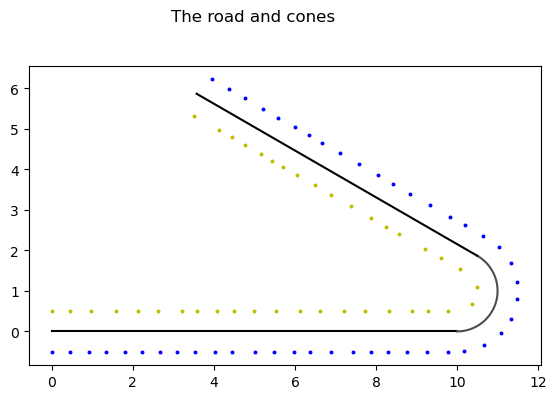

In [246]:
# Import the funcion
from evaluation.evaluation_for_autonomous_driving import plot_road_from_list_of_road_elements

# Specify a suffix for the plot file names
file_name_suffix = "with_cones"

# Call the plotting function
road_plot_details = plot_road_from_list_of_road_elements(road_elements_list, path_for_saving_figures, file_name_suffix, width_btw_cones=width_btw_cones, mean_length_btw_cones=mean_length_btw_cones, stddev_of_length_btw_cones=stddev_of_length_btw_cones)

### Specify the details of generating cone observation

These specifications are described in the the "AI4R_Gym_Observations_Explanation.pdf" file that is provided on [Workshop Material page](https://canvas.lms.unimelb.edu.au/courses/187349/pages/workshop-materials-2) on LMS

In [247]:
cone_detections_fov_horizontal_degrees         =  80.0
cone_detections_body_x_upper_bound             =  4.0
cone_detections_stddev_of_detection_in_body_x  =  0.2
cone_detections_stddev_of_detection_in_body_y  =  0.1

## Environment Settings

**IMPORTANT NOTE**

The steering offset parameter in the bicycle model is set to 0 degrees, i.e., `"delta_offset" : 0.0 * np.pi/180,`.

This steering offset can be an important parameter to consider for matching simulation peformance and real-world behaviour.

### Specify the Vehicle Parameters

Dictionary with car specifications,
in the form of a dynamic bicycle model.

The model parameters values here are very loosely intended to match a 1/10 scale Traxxas Slash RC car.

In [248]:
# SPECIFY THE VEHCILE PARAMETERS
bicycle_model_parameters = {
    "Lf" : 0.60*0.33,
    "Lr" : 0.40*0.33,
    "m"  : 3.0,
    "Iz" : (1.0/12.0) * 3.0 * (0.40**2+0.25**2),
    "Cm" : (1.0/100.0) * 10.0,
    "Cd" : 1.0,
    "delta_offset" : 0.0 * np.pi/180,
    "delta_request_max" : 45 * np.pi/180,
    "Ddelta_lower_limit" : -90 * np.pi/180,
    "Ddelta_upper_limit" :  90 * np.pi/180,
    "v_transition_min" : 500.0 / 3.6,
    "v_transition_max" : 600.0 / 3.6,
    "body_len_f" : (0.60*0.33) * 1.5,
    "body_len_r" : (0.40*0.33) * 1.5,
    "body_width" : 0.25,
}

### Specify the Observation Parameters

To make this more precise, we have remove the parameters that are not necessary for this example. Those parameters that are left out are automatically set to default values by the Gymnasium.

In [249]:
# SPECIFY THE OBSERVATION PARAMETERS
observation_parameters = {
    "should_include_ground_truth_px"                       :  "info",
    "should_include_ground_truth_py"                       :  "info",
    "should_include_ground_truth_theta"                    :  "info",
    "should_include_ground_truth_vx"                       :  "info",
    "should_include_ground_truth_vy"                       :  "info",
    "should_include_ground_truth_omega"                    :  "info",
    "should_include_ground_truth_delta"                    :  "info",
    "should_include_road_progress_at_closest_point"        :  "info",
    "should_include_vx_sensor"                             :  "obs",
    "should_include_distance_to_closest_point"             :  "obs",
    "should_include_heading_angle_relative_to_line"        :  "obs",
    "should_include_heading_angular_rate_gyro"             :  "info",
    "should_include_closest_point_coords_in_body_frame"    :  "info",
    "should_include_look_ahead_line_coords_in_body_frame"  :  "neither",
    "should_include_road_curvature_at_closest_point"       :  "neither",
    "should_include_look_ahead_road_curvatures"            :  "neither",
    "should_include_cone_detections"                       :  "obs",

    "vx_sensor_bias"    : 0.0,
    "vx_sensor_stddev"  : 0.1, #0.1

    "cone_detections_width_btw_cones"             :  width_btw_cones,
    "cone_detections_mean_length_btw_cones"       :  mean_length_btw_cones,
    "cone_detections_stddev_of_length_btw_cones"  :  stddev_of_length_btw_cones,

    "cone_detections_fov_horizontal_degrees"         :  cone_detections_fov_horizontal_degrees,
    "cone_detections_body_x_upper_bound"             :  cone_detections_body_x_upper_bound,
    "cone_detections_stddev_of_detection_in_body_x"  :  cone_detections_stddev_of_detection_in_body_x,
    "cone_detections_stddev_of_detection_in_body_y"  :  cone_detections_stddev_of_detection_in_body_y,
}

###  Specify the Initial State Distribution

The initial state is sampled from a uniform
distribution between the minimum and maximum
(i.e., between lower and upper bounds)
> Note: a factor of (1/3.6) converts from units of [km/h] to [m/s]

In [250]:
py_init_min = -0.1
py_init_max =  0.1

v_init_min_in_meters_per_sec = 1.0
v_init_max_in_meters_per_sec = 1.0

initial_state_bounds = {
    "px_init_min" : 0.0,
    "px_init_max" : 0.0,
    "py_init_min" : py_init_min,
    "py_init_max" : py_init_max,
    "theta_init_min" : 0.0,
    "theta_init_max" : 0.0,
    "vx_init_min" : v_init_min_in_meters_per_sec,
    "vx_init_max" : v_init_min_in_meters_per_sec,
    "vy_init_min" : 0.0,
    "vy_init_max" : 0.0,
    "omega_init_min" : 0.0,
    "omega_init_max" : 0.0,
    "delta_init_min" : 0.0,
    "delta_init_max" : 0.0,
}

### Specify Termination Parameters

In [251]:
termination_parameters = {
    "speed_lower_bound"  :  0.0,
    "speed_upper_bound"  :  10.0,
    "distance_to_closest_point_upper_bound"  :  20.0,
    "reward_speed_lower_bound"  :  0.0,
    "reward_speed_upper_bound"  :  0.0,
    "reward_distance_to_closest_point_upper_bound"  :  0.0,
}

### Specify the Numerical Integration Details

The options available for the numerical
integration method are:
`["euler", "huen", "midpoint", "rk4", "rk45"]`


In [252]:
numerical_integration_parameters = {
    "method" : "rk4",
    "Ts" : 0.05,
    "num_steps_per_Ts" : 1,
}

## Initialise the Autonomous Driving Environment

Options available for the "render_mode" are:
`["matplotlib", None]`

In [253]:
env_base = gym.make(
    "ai4rgym/autonomous_driving_env",
    render_mode=None,
    bicycle_model_parameters=bicycle_model_parameters,
    road_elements_list=road_elements_list,
    numerical_integration_parameters=numerical_integration_parameters,
    termination_parameters=termination_parameters,
    initial_state_bounds=initial_state_bounds,
    observation_parameters=observation_parameters,
)

### Verify Environment

In [254]:
# Reset the gymnasium
# > which also returns the first observation
observation, info_dict = env_base.reset()

/opt/anaconda3/envs/elen90095/lib/python3.13/site-packages/gymnasium/utils/passive_env_checker.py:134: UserWarning: WARN: The obs returned by the `reset()` method was expecting numpy array dtype to be float32, actual type: float64
  logger.warn(
/opt/anaconda3/envs/elen90095/lib/python3.13/site-packages/gymnasium/utils/passive_env_checker.py:158: UserWarning: WARN: The obs returned by the `reset()` method is not within the observation space.
  logger.warn(f"{pre} is not within the observation space.")


In [255]:
observation

{'vx_sensor': array([0.82999814], dtype=float32),
 'distance_to_closest_point': array([-0.05162], dtype=float32),
 'heading_angle_relative_to_line': array([0.], dtype=float32),
 'recommended_speed': array([27.777779], dtype=float32),
 'cone_detections_x': array([0.66639191, 1.47335421, 1.87356916, 2.24814039, 2.75806382,
        3.54043111, 1.25472263, 1.17890444, 2.14619838, 2.37201979,
        3.18521883, 3.72477899, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ]),
 'cone_detections_y': array([ 0.47730043,  0.57261951,  0.58829683,  0.63362224,  0.41822175,
         0.4147113 , -0.5834256 , -0.46420799, -0.49580859, -0.42563729,
        -0.41606956, -0.56964149,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        

In [256]:
info_dict

{'ground_truth_px': array([0.], dtype=float32),
 'ground_truth_py': array([-0.05162], dtype=float32),
 'ground_truth_theta': array([0.], dtype=float32),
 'ground_truth_vx': array([1.], dtype=float32),
 'ground_truth_vy': array([0.], dtype=float32),
 'ground_truth_omega': array([0.], dtype=float32),
 'ground_truth_delta': array([0.], dtype=float32),
 'road_progress_at_closest_point': array([0.], dtype=float32),
 'steering_angle_sensor': array([0.], dtype=float32),
 'heading_angular_rate_gyro': array([0.], dtype=float32),
 'closest_point_coords_in_body_frame': array([0.     , 0.05162], dtype=float32),
 'speed_limit': array([27.777779], dtype=float32),
 'next_speed_limit': array([27.777779], dtype=float32),
 'distance_to_next_speed_limit': array([1000.], dtype=float32),
 'next_recommended_speed': array([4.1666665], dtype=float32),
 'distance_to_next_recommended_speed': array([10.], dtype=float32)}

In [257]:
env_base.observation_space

Dict('cone_detections_num_cones': MultiDiscrete([28]), 'cone_detections_side_of_road': MultiDiscrete([3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3]), 'cone_detections_x': Box(-inf, inf, (27,), float32), 'cone_detections_y': Box(-inf, inf, (27,), float32), 'distance_to_closest_point': Box(-inf, inf, (1,), float32), 'heading_angle_relative_to_line': Box(-3.1415927, 3.1415927, (1,), float32), 'recommended_speed': Box(-inf, inf, (1,), float32), 'vx_sensor': Box(-inf, inf, (1,), float32))

In [258]:
env_base.action_space

Box([-100.          -0.7853982], [100.          0.7853982], (2,), float32)

In [259]:
random_action = env_base.action_space.sample()

In [260]:
observation, reward, terminated, truncated, info = env_base.step(random_action)

In [261]:
observation

{'vx_sensor': array([1.0611842], dtype=float32),
 'distance_to_closest_point': array([-0.05258653], dtype=float32),
 'heading_angle_relative_to_line': array([0.00644819], dtype=float32),
 'recommended_speed': array([27.777779], dtype=float32),
 'cone_detections_x': array([0.7025429 , 1.6153977 , 1.9864551 , 2.2403312 , 2.8686037 ,
        3.4617307 , 3.6728835 , 0.52516174, 1.2245884 , 1.8345444 ,
        2.3037498 , 3.2930858 , 3.7385948 , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        ], dtype=float32),
 'cone_detections_y': array([ 0.5469932 ,  0.60037434,  0.45731038,  0.5577994 ,  0.49329826,
         0.6003318 ,  0.44509274, -0.5312073 , -0.4963293 , -0.46761462,
        -0.34079248, -0.3896457 , -0.50925446,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,

In [262]:
reward

0.0

In [263]:
info

{'ground_truth_px': array([0.05309958], dtype=float32),
 'ground_truth_py': array([-0.05258652], dtype=float32),
 'ground_truth_theta': array([-0.00644819], dtype=float32),
 'ground_truth_vx': array([1.1233804], dtype=float32),
 'ground_truth_vy': array([-0.03536479], dtype=float32),
 'ground_truth_omega': array([-0.26791507], dtype=float32),
 'ground_truth_delta': array([-0.07853982], dtype=float32),
 'road_progress_at_closest_point': array([0.05309958], dtype=float32),
 'steering_angle_sensor': array([-0.07853982], dtype=float32),
 'heading_angular_rate_gyro': array([-0.26791507], dtype=float32),
 'closest_point_coords_in_body_frame': array([-0.00033909,  0.05258543], dtype=float32),
 'speed_limit': array([27.777779], dtype=float32),
 'next_speed_limit': array([27.777779], dtype=float32),
 'distance_to_next_speed_limit': array([1000.], dtype=float32),
 'next_recommended_speed': array([4.1666665], dtype=float32),
 'distance_to_next_recommended_speed': array([9.9469], dtype=float32),
 

### Reward Wrapper

We set the reward equal to zero because the reward function is not the focus of this example notebook. Hence, setting the reward to zero hopefully make the reward less of a distraction.

In [264]:
class RewardWrapper(gym.Wrapper):
    def __init__(self, env):
        super(RewardWrapper, self).__init__(env)

    def step(self, action):
        observation, reward, terminated, truncated, info = self.env.step(action)

        # Ground Truth
        gt = self.env.unwrapped.current_ground_truth

        # Observations
        heading_err = float(abs(gt["heading_angle_relative_to_line"])) # In radians
        distance = float(abs(gt["distance_to_closest_point"])) # In meters
        steering = float(abs(action[0]))

        # Parameters
        k_center = 2.0
        k_heading = 0.5
        k_smooth = 0.1

        # Reward Components
        r_center = k_center * (1.0 / (1.0 + distance**2)) 
        r_heading = -k_heading * (1.0 / (1.0 + heading_err**2)) # Penalize large heading error (quadratic for stronger signal)
        r_smooth = -k_smooth * (1.0 / (1.0 + steering**2)) # Penalize large steering actions (quadratic)

        # Create your own reward here
        reward = 0 #r_center + r_heading + r_smooth

        return observation, reward, terminated, truncated, info

Create a new environment and wrap it with the Reward Wrapper

In [265]:
env_base = gym.make(
    "ai4rgym/autonomous_driving_env",
    render_mode=None,
    bicycle_model_parameters=bicycle_model_parameters,
    road_elements_list=road_elements_list,
    numerical_integration_parameters=numerical_integration_parameters,
    termination_parameters=termination_parameters,
    initial_state_bounds=initial_state_bounds,
    observation_parameters=observation_parameters,
)

# Set the road condition
env_base.unwrapped.set_road_condition(road_condition="dry")

# Add the reward wrapper
env_with_reward_wrapper = RewardWrapper(env_base)

Let's check the reward now:

In [266]:
observation, info = env_with_reward_wrapper.reset()
random_action = env_with_reward_wrapper.action_space.sample()
observation, reward, terminated, truncated, info = env_with_reward_wrapper.step(random_action)
print(reward)

0


## Define a Policy Class for Cone Following

This is the same policy that is provide in the policy_node.py of the ai4r-system git repository.

As explaining during class, this policy is provided to show you the definitions, the use, and the flow of data.

Once you feel comfortable with the observation and action data, then you should delete this policy and develop your own policy from scratch.

In [267]:
# ---------------------
#  LINEAR POLICY CLASS
# ---------------------
class PIDPolicyForConeFollowing:
    """
    This class implements a policy for Autonomus Driving
    that mostly matches the policy provided in the policy_node
    """

    def __init__(self):
        """
        Initialization function for the "PIDPolicyForAutonomousDriving" class.
        """
        self.speed_ref = 1.0
        self.drive_command_baseline = 10.0
        self.kp_cruise_control = 4.0

        # Change Line
        self.sim_num = 0
        self.line_state = 0



    def compute_action(self, observation, info_dict, terminated, truncated):
        # Set the speed reference
        speed_ref = self.speed_ref
        # Zero speed reference after reaching the end of the road
        if (terminated or truncated):
            speed_ref = 0.0

        # Simple Proportional-only controll for speed control
        # > Get the speed observation of the car
        speed = observation["vx_sensor"][0]
        # > Compute the error between the reference and actual speed
        speed_error = speed_ref - speed
        # > Compute the drive command action
        drive_command_raw = self.drive_command_baseline + self.kp_cruise_control * speed_error
        # > Clip the drive command action to be in the range [-100,100] percent
        drive_command_clipped = max(-100.0, min(drive_command_raw, 100.0))

        # Initialise the steering request to zero
        delta_request = 0.0



        # Extract the number of cones
        num_cones = observation["cone_detections_num_cones"][0]
        # > On the real car, this is:
        #num_cones = msg.n

        # Extract the coordinates and colour of each cone
        # > Note: multiplying by 1000.0 to convert from meters to millimeters
        x_coords_np_array = observation["cone_detections_x"][:num_cones] * 1000.0
        y_coords_np_array = observation["cone_detections_y"][:num_cones] * 1000.0
        x_coords = x_coords_np_array.tolist()
        y_coords = y_coords_np_array.tolist()
        cone_colour = observation["cone_detections_side_of_road"][:num_cones].tolist()

        #print(x_coords)

        # > On the real car, this is:
        #x_coords = msg.x
        #y_coords = msg.y
        #cone_colour = msg.c

        # =======================================
        # START OF: INSERT POLICY CODE BELOW HERE
        # =======================================

        # OBSERVATIONS:
        # > The "x_coords", "y_coords" and "cone_colour" variable are:
        #   - Lists with length equal to num_cones (the number of cones detected).
        #   - "x_coords" and "y_coords" give the x and y world coordinates of the cones respectively
        #   - "cone_colour" gives the colour of the cones (0 for yellow, 1 for blue)
        #   - A cone represents a single index of all three lists e.g. x_coords[i], y_coords[i], cone_colour[i] represent the ith cone

        # ACTIONS:
        # > The "esc_action" is:
        #   - The action for driving the main motor (esc := electronic speed contrller).
        #   - In units of signed percent, with valid range [-100,100]
        # > The "steering_action" is:
        #   - The action for changing the position of the steering servo.
        #   - In units of signed percent, with valid range [-100,100]

        # ACRONYMS:
        # "esc" := Electronic Speed Controller
        #   - This device on the Traxxas car does NOT control the speed.
        #   - The "esc" device set the voltage to the motor within the
        #     range [-(max voltage),+(max voltage)]


        # =====================================
        # START OF SIMPLE POLICY
        # =====================================
        ROAD_WIDTH = 1000            # Width of the Road (in mm)
        P_STEERING = 0.0005           # P value for Steering Action
        STEER_OFFSET = 0             # Offset to adjust for biased steering
        #FIXED_ESC_VALUE = 33.0      # Fixed ESC value for steering tests

        yellow_line = False          # Flag to signal yellow line detection
        blue_line = False            # Flag to signal blue line detection

        # Convert to arrays for convenience
        x_array = np.array(x_coords)
        y_array = np.array(y_coords)
        c_array = np.array(cone_colour)

        # Create boolean masks based on c_np for yellow (0) and blue (1)
        yellow_mask = (c_array == 0)
        blue_mask = (c_array == 1)

        # Filter co-ordinates based on color
        bx = x_array[blue_mask]
        by = y_array[blue_mask]
        yx = x_array[yellow_mask]
        yy = y_array[yellow_mask]

        # Fit a line to yellow points if there are enough points (>=2 points)
        if len(yx) > 1:
            try:
                yellow_fit = np.polyfit(yx, yy, 1)  # Linear fit (y = mx + b)
                yellow_line = True
                #self.get_logger().info("Yellow line fit: gradient = " + str(yellow_fit[0]) + "y-intercept + " + str(yellow_fit[1]))
            except:
                print("Could not fit yellow line")
                #self.get_logger().info("Could not fit yellow line")

        else:
            print("Not enough yellow cones detected")
            #self.get_logger().info("Not enough yellow cones detected")

        # Fit a line to blue points if there are enough points
        if len(bx) > 1:
            try:
                blue_fit = np.polyfit(bx, by, 1)  # Linear fit (y = mx + b)
                blue_line = True
                #self.get_logger().info("Blue line fit: gradient = " + str(blue_fit[0]) + "y-intercept + " + str(blue_fit[1]))
            except:
                print("Could not fit blue line")
                #self.get_logger().info("Could not fit blue line")
        else:
            print("Not enough blue cones detected")
            #self.get_logger().info("Not enough blue cones detected")

        if yellow_line and blue_line:
            # CENTRE Line: Average the coefficients of the yellow and blue lines
            m = (yellow_fit[0] + blue_fit[0]) / 2
            b = (yellow_fit[1] + blue_fit[1]) / 2

            # ********** For Object Detection **********
            # ADDED: Line between BLUE cones and CENTRE
            m_blue = (blue_fit[0] + m) / 2
            b_blue = (blue_fit[1] + b) / 2
            # ADDED: Line between YELLOW cones and CENTRE
            m_yellow = (yellow_fit[0] + m) / 2
            b_yellow = (yellow_fit[1] + b) / 2

            if self.line_state == 1:
                m = (yellow_fit[0] + m) / 2
                b = (yellow_fit[1] + b) / 2
            elif self.line_state == -1:
                m = (blue_fit[0] + m) / 2
                b = (blue_fit[1] + b) / 2
            
        elif yellow_line:
            m = yellow_fit[0]
            b = yellow_fit[1] - ROAD_WIDTH / 2  # Offset calculation if only yellow line found
            
        elif blue_line:
            m = blue_fit[0]
            b = blue_fit[1] + ROAD_WIDTH / 2    # Offset calculation if only blue line found
        else:
            m, b = False, False

        if m and b:
            # Evaluate the distance-to-line at some look ahead distance in front of the car
            look_ahead_dist = 1000.0 # (Units: millimeters)
            distance_to_target_line = m * look_ahead_dist + b
            steering_action = P_STEERING * distance_to_target_line + STEER_OFFSET
            #print(f"Dist-to-line = {distance_to_target_line:.2f}, steer action = {steering_action:.2f}")
            # self.get_logger().info(f"Steering action: {steering_action:.2f}")
            #esc_action = FIXED_ESC_VALUE
        else:
            print("Could not fit any line")
            #self.get_logger().info("Could not fit any line")
            steering_action = 0.0
            drive_command_clipped = 0.0
            #esc_action = 0.0
            # LOGIC FOR TERMINATION

        # =====================================
        # END OF SIMPLE POLICY
        # =====================================

        # Convert the [-100,100] percentage stering action
        # into a steering angle
        steering_action_clipped = max(-100.0, min(steering_action, 100.0))
        delta_request = steering_action_clipped * bicycle_model_parameters["delta_request_max"]

        self.sim_num += 1

        if self.sim_num > 100:
            self.line_state = -1
        if self.sim_num > 300:
            self.line_state = +1


        # =====================================
        # END OF: INSERT POLICY CODE ABOVE HERE
        # =====================================



        # Construct the action vector expected by the gymnasium
        action = np.array([drive_command_clipped,delta_request], dtype=np.float32)

        # Return the action
        return action

In [1022]:
class PIDPolicyForConeFollowing:
    """
    This class implements a policy for Autonomus Driving
    that mostly matches the policy provided in the policy_node
    """

    def __init__(self):
        """
        Initialization function for the "PIDPolicyForAutonomousDriving" class.
        """
        self.speed_ref = 10.0
        self.drive_command_baseline = 10.0
        self.kp_cruise_control = 4.0
        
        self.prev_lateral_error = 0.0
        self.integral_lateral_error = 0.0

        self.timer_period = 0.05  # seconds per control step (example)

    
    def compute_action(self, observation, info_dict, terminated, truncated):
        # Set the speed reference
        speed_ref = self.speed_ref
        # Zero speed reference after reaching the end of the road
        if (terminated or truncated):
            speed_ref = 0.0

        # Simple Proportional-only controll for speed control
        # > Get the speed observation of the car
        speed = observation["vx_sensor"][0]
        # > Compute the error between the reference and actual speed
        speed_error = speed_ref - speed
        # > Compute the drive command action
        drive_command_raw = self.drive_command_baseline + self.kp_cruise_control * speed_error
        # > Clip the drive command action to be in the range [-100,100] percent
        drive_command_clipped = max(-100.0, min(drive_command_raw, 100.0))

        # Initialise the steering request to zero
        delta_request = 0.0

        # Extract the number of cones
        num_cones = observation["cone_detections_num_cones"][0]
        # > On the real car, this is:
        #num_cones = msg.n

        # Extract the coordinates and colour of each cone
        # > Note: multiplying by 1000.0 to convert from meters to millimeters
        x_coords_np_array = observation["cone_detections_x"][:num_cones] * 1000.0
        y_coords_np_array = observation["cone_detections_y"][:num_cones] * 1000.0
        x_coords = x_coords_np_array.tolist()
        y_coords = y_coords_np_array.tolist()
        
        # + COMMENTED: Colours are not considered anymore - instead, LEFT or RIGHT
        cone_colour = observation["cone_detections_side_of_road"][:num_cones].tolist()

        # + Heading Angle (in rads)
        heading_angle_in_radians = observation["heading_angle_relative_to_line"][0]

        # > On the real car, this is:
        #x_coords = msg.x
        #y_coords = msg.y
        #cone_colour = msg.c

        # =======================================
        # START OF: INSERT POLICY CODE BELOW HERE
        # =======================================

        # OBSERVATIONS:
        # > The "x_coords", "y_coords" and "cone_colour" variable are:
        #   - Lists with length equal to num_cones (the number of cones detected).
        #   - "x_coords" and "y_coords" give the x and y world coordinates of the cones respectively
        #   - "cone_colour" gives the colour of the cones (0 for yellow, 1 for blue)
        #   - A cone represents a single index of all three lists e.g. x_coords[i], y_coords[i], cone_colour[i] represent the ith cone

        # ACTIONS:
        # > The "esc_action" is:
        #   - The action for driving the main motor (esc := electronic speed contrller).
        #   - In units of signed percent, with valid range [-100,100]
        # > The "steering_action" is:
        #   - The action for changing the position of the steering servo.
        #   - In units of signed percent, with valid range [-100,100]

        # ACRONYMS:
        # "esc" := Electronic Speed Controller
        #   - This device on the Traxxas car does NOT control the speed.
        #   - The "esc" device set the voltage to the motor within the
        #     range [-(max voltage),+(max voltage)]

        # ===============================================================================================================
        #                                               AMAZING POLICY
        # ===============================================================================================================

        # ---------------------------------------------------------------------------------------------------------------
        #                                           VARIABLES AND CONSTANTS
        # ---------------------------------------------------------------------------------------------------------------

        # + PID and Gain values
        P_STEERING = 0.0005  # P value for Steering Action; SIM=0.0005; DEFAULT=0.25
        I_STEERING = 0.000002  # + I value for Steering Action; SIM=0.000002; DEFAULT=0.001
        I_ADAPTION = .9  # + Adaption rate for the integral term; DEFAULT=0.9
        D_STEERING = 0.000025  # + D value for Steering Action; SIM=0.000025; DEFAULT=0.0125

        # + Smoothing Gains
        HEADING_GAIN = 0.0001  # + Gain for heading error correction; SIM=0.0001; DEFAULT=0.05
        CURVATURE_OFFSET_GAIN = 25.0  # + Gain for curvature-based offset scaling; DEFAULT=25.0
        BIAS_GAIN = 0.25  # + Gain for curvature-based biasing of lane centre; DEFAULT=0.25
        BIAS_LIMIT = 0.2  # + Limit for curvature-based biasing of lane centre; DEFAULT=0.4

        # + Smoothing Factors
        ALPHA_HEADING = .25  # + Weight for PCA (0.0 = pure IMU, 1.0 = pure PCA); DEFAULT=0.25
        ALPHA_LANE_CENTRE = .8  # + Smoothing factor for lane centre estimation; DEFAULT=0.8
        ALPHA_LANE_HALFWIDTH = .2  # + Smoothing factor for lane width estimation; DEFAULT=0.2

        # + Steering Adjustment Values
        STEER_OFFSET = 0  # Offset to adjust for biased steering; DETAULT=0
        FIXED_ESC_VALUE = 15.0  # Fixed ESC value for steering tests; DEFAULT=33.0

        # + Lane Width Definitions (in mm)
        DEFAULT_LANE_HALFWIDTH = 500.0  # Default lane half-width when only one side is detected (CAR_WIDTH≈300mm); DEFAULT=600.0

        # + Lookahead Window Definition(in mm)
        X_MIN = 500.0  # Start of lookahead window; SIM=500.0; DETAULT=50.0
        X_MAX = 8_000.0  # End of lookahead window; SIM=8_000.0; DEFAULT=2000.0
        X_LOOKAHEAD = 1000.0  # Lookahead point (where we aim to be in the centre of the road); SIM=1000.0; DEFAULT=800.0
        ANGLE_THRESHOLD = 10.0  # Max heading angle (in degrees) to consider INVALID cone detections; DETAULT=10.0

        # ---------------------------------------------------------------------------------------------------------------
        #                                               HELPER FUNCTIONS
        # ---------------------------------------------------------------------------------------------------------------

        # + Filter cones based on Lookahead Window and Front View Restrictions
        def filter_forward_cones(x_coords, y_coords, cone_colour):
            # Convert to arrays for convenience
            x_array = np.array(x_coords, dtype=float)  # Forward (in mm)
            y_array = np.array(y_coords, dtype=float)  # Lateral (in mm)
            c_array = np.array(cone_colour, dtype=int)  # Colour (0=yellow, 1=blue)

            # + Apply forward window (we only get the cones values within range)
            window_mask = (x_array >= X_MIN) & (x_array <= X_MAX)
            x_window, y_window, c_window = x_array[window_mask], y_array[window_mask], c_array[window_mask]

            # + Compute angle θ = atan2(y, x) for each cone within the window
            theta = np.arctan2(y_window, x_window)  # In radians

            # + Apply front view restriction (we only keep cones within the angle threshold)
            angle_mask = np.abs(np.degrees(theta)) > ANGLE_THRESHOLD

            return x_window[angle_mask], y_window[angle_mask], c_window[angle_mask]
        
        # + Compute dominant road direction using PCA
        def compute_PCA_road_direction(x, y):
            # + If enough info, we assume forwards direction
            if len(x) < 2:
                return np.array([1.0, 0.0])  

            # + Prepare points for PCA
            pts = np.column_stack((x, y)).astype(float)
            mean = np.mean(pts, axis=0)
            centered = pts - mean
            
            # + Compute covariance matrix and its eigenvalues/vectors
            cov = np.cov(centered.T)
            eigvals, eigvecs = np.linalg.eig(cov)  # + Eigen decomposition of covariance matrix
            principal_axis = eigvecs[:, np.argmax(eigvals)]  # + Principal axis corresponds to largest eigenvalue

            # + Ensure principal axis points forwards (positive x direction)
            if principal_axis[0] < 0:
                principal_axis = -principal_axis

            return principal_axis / np.linalg.norm(principal_axis)  # + Normalize
        
        # + Estimate curvature of a side's cones using quadratic fit
        def estimate_curvature(x_side, y_side):
            # + If insufficient points, return zero curvature (assume straight line)
            if len(x_side) < 3:
                return 0.0 
            
            # + Fit a quadratic polynomial y = ax^2 + bx + c
            coeffs = np.polyfit(x_side, y_side, deg=2)
            a, b, c = coeffs

            # + Compute curvature at lookahead point (kappa≈2a/(1+(dy/dx)^2)^(3/2))
            dy_dx = 2 * a * X_LOOKAHEAD + b  # + First derivative at lookahead
            curvature = abs(2 * a / ((1 + dy_dx**2) ** 1.5))

            return curvature
        
        # ---------------------------------------------------------------------------------------------------------------
        #                                                 MAIN FUNCTIONS
        # ---------------------------------------------------------------------------------------------------------------

        # + Compute heading error between PCA-based lane heading and IMU heading
        def compute_heading_error(self, x, y, heading_angle_in_radians):
            # + COMPUTE DOMINANT ROAD DIRECTION and PCA-BASED HEADING
            road_direction = compute_PCA_road_direction(x, y)
            pca_heading = np.arctan2(road_direction[1], road_direction[0])  # + PCA-based heading angle (in rads)

            # + USE CURRENT PCA HEADING as PREVIOUS if none exists
            if not hasattr(self, "prev_lane_heading_rad"):
                self.prev_lane_heading_rad = pca_heading

            # + SMOOTH the PCA HEADING with previous estimate (using exponential moving average)
            lane_heading_rad = ALPHA_HEADING * pca_heading + (1 - ALPHA_HEADING) * self.prev_lane_heading_rad

            # + UPDATE previous lane heading estimate
            self.prev_lane_heading_rad = lane_heading_rad

            # + COMPUTE HEADING ERROR relative to IMU heading
            heading_error = (lane_heading_rad - heading_angle_in_radians + np.pi) % (2 * np.pi) - np.pi  # + Normalized to [-pi, pi]

            return heading_error
        
        # + Compute lateral error to lane centre at lookahead pointy
        def compute_lateral_error(self, x_left, y_left, x_right, y_right):
            # + CHECK if we have at least one cone on each side
            valid_left, valid_right = len(x_left) >= 2, len(x_right) >= 2

            # + IF we have cones on both sides
            if valid_left and valid_right:
                # + COMPUTE LANE CENTER at LOOKAHEAD point by averaging closest cones on each side
                left_fit = np.polyfit(x_left, y_left, deg=1)
                right_fit = np.polyfit(x_right, y_right, deg=1)
                # + PREDICT y values at LOOKAHEAD point
                y_left_fit = np.polyval(left_fit, X_LOOKAHEAD)
                y_right_fit = np.polyval(right_fit, X_LOOKAHEAD)
                # + LANE CENTER is average of both sides
                y_lane_center = 0.5 * (y_left_fit + y_right_fit)

                # + ESTIMATE CURVATURE for each side using quadratic fit
                curvature_left = estimate_curvature(x_left, y_left)
                curvature_right = estimate_curvature(x_right, y_right)
                curvature = 0.5 * (curvature_left + curvature_right)  # + Average curvature from both sides for ESC control

                # Compute normalized curvature difference
                curv_sum = curvature_left + curvature_right + 1e-6  # + Small constant to avoid division by zero
                bias = (curvature_right - curvature_left) / curv_sum  # + Bias based on curvature difference (-1.0 to +1.0)
                bias = np.clip(bias, -BIAS_LIMIT, BIAS_LIMIT)  # + Limit bias so it doesn’t overcompensate (-BAIS_LIMIT to +BIAS_LIMIT)

                # + COMPUTE CURVATURE-BASED LANE CENTRE ADJUSTMENT
                curvature_bias_factor = BIAS_GAIN * bias  # + Curvature-based bias factor (-BIAS_GAIN to +BIAS_GAIN)
                lane_width = abs(y_left_fit - y_right_fit)  # + Current lane width at lookahead
                lateral_offset_compensation = curvature_bias_factor * lane_width  # + Lateral offset compensation (in mm)
                # + ADJUST LANE CENTER based on curvature bias
                y_lane_center += lateral_offset_compensation

                # Save last known halfwidth for fallback use
                if hasattr(self, "last_lane_halfwidth"):
                    self.last_lane_halfwidth = ALPHA_LANE_HALFWIDTH * self.last_lane_halfwidth + (1 - ALPHA_LANE_HALFWIDTH) * (lane_width / 2.0)
                else:
                    self.last_lane_halfwidth = lane_width / 2.0

            # + ELSE IF we have cones on only one side
            elif valid_left or valid_right:
                # + GET the side with valid cones and FIT line
                x_side, y_side = (x_left, y_left) if valid_left else (x_right, y_right)
                side_fit = np.polyfit(x_side, y_side, deg=1)
                # + PREDICT y values at LOOKAHEAD point
                y_side_fit = np.polyval(side_fit, X_LOOKAHEAD)

                # + ESTIMATE CURVATURE using quadratic fit
                curvature = estimate_curvature(x_side, y_side)

                # + Use DEFAULT lane half-width if no previous measurement
                if hasattr(self, "last_lane_halfwidth"):
                    lane_halfwidth = self.last_lane_halfwidth
                else:
                    lane_halfwidth = DEFAULT_LANE_HALFWIDTH

                # Inward offset (smaller on tight curves)
                offset_scale = 1 / (1 + CURVATURE_OFFSET_GAIN * curvature)  # + Scale offset based on curvature (0.0 to 1.0)
                dynamic_offset = lane_halfwidth * offset_scale  # + Dynamic lateral offset (in mm)
                
                # ⚠️⚠️⚠️ CHANGE THE SIGNS FOR THE REAL WORLD CAR ⚠️⚠️⚠️
                y_lane_center = y_side_fit + abs(dynamic_offset) if valid_left else y_side_fit - abs(dynamic_offset)  # + Adjust lane center based on side

            # + ELSE, if no cones detected on either side
            else:
                # + FALLBACK to previous lane center if exists
                if hasattr(self, "prev_lane_center_y"):
                    y_lane_center = self.prev_lane_center_y
                else:
                    y_lane_center = 0.0  # Initial neutral fallback

                # + ASSUME STRAIGHT ROAD if no cones detected
                curvature = 0.0
            
            # + Use CURRENT LANE CENTER as PREVIOUS if none exists
            if not hasattr(self, "prev_lane_center_y"):
                    self.prev_lane_center_y = y_lane_center
            
            # + SMOOTH LANE CENTER with previous estimate
            y_lane_center = (1 - ALPHA_LANE_CENTRE) * y_lane_center + ALPHA_LANE_CENTRE * self.prev_lane_center_y
            self.prev_lane_center_y = y_lane_center  # + Update previous lane center

            return y_lane_center, curvature

        # + Compute steering action using PID controller
        def compute_steering_action(self, lateral_error, heading_error):
            # + USE CURRENT LATERAL ERROR as PREVIOUS on initialisation
            if not hasattr(self, "prev_lateral_error"):
                self.prev_lateral_error = lateral_error

            # + COMPUTE DERIVATIVE of lateral error
            derivative_error = (lateral_error - self.prev_lateral_error) / self.timer_period 
            # + UPDATE INTEGRAL of lateral error with ADAPTION
            self.integral_lateral_error = ((1 - I_ADAPTION) * self.integral_lateral_error 
                                           + I_ADAPTION * lateral_error * self.timer_period)

            # + COMPUTE STEERING AND ESC ACTIONS
            steering_action = (
                P_STEERING * lateral_error  # P term for lateral error
                + I_STEERING * self.integral_lateral_error  # I term for lateral error
                + D_STEERING * derivative_error  # D term for lateral error
                + HEADING_GAIN * np.degrees(heading_error)  # Heading error correction (PCA-based)
                + STEER_OFFSET)
            
            # + UPDATE previous lateral error
            self.prev_lateral_error = lateral_error

            # + CLIP STEERING ACTION to valid range
            steering_action = np.clip(steering_action, -100.0, 100.0)
            
            return steering_action
        
        # + Compute fixed esc action to maintain forward motion
        def compute_esc_action(self, curvature):
            esc_action = FIXED_ESC_VALUE  # Keep forward motion
            return esc_action

        # ---------------------------------------------------------------------------------------------------------------
        #                                                 POLICY LOGIC
        # ---------------------------------------------------------------------------------------------------------------

        # + FILTER the cones to only keep those in FRONT of the car within the lookahead window
        x, y, c = filter_forward_cones(x_coords, y_coords, cone_colour)

        # + NO CONES DETECTED after filtering; maintain previous actions
        if len(x) == 0:
            steering_action = 0.0
            esc_action = 0.0

        # + CONES DETECTED; proceed with policy computations
        else:
            # + COMPUTE HEADING ERROR between PCA-based lane heading and IMU heading
            heading_error = compute_heading_error(self, x, y, heading_angle_in_radians)

            # + SEPARATE BLUE cones (left) and YELLOW cones (right)
            x_left, y_left, x_right, y_right = x[c == 1], y[c == 1], x[c == 0], y[c == 0]
            # + GET LATERAL ERROR to LANE CENTRE and CURVATURE
            y_lane_center, curvature = compute_lateral_error(self, x_left, y_left, x_right, y_right)

            # + COMPUTE LATERAL ERROR to the target line at LOOKAHEAD TARGET POINT
            lateral_error = y_lane_center

            # COMPUTE STEERING ACTION using PID controller and ESC ACTION to maintain forward motion
            steering_action = compute_steering_action(self, lateral_error, heading_error)
            esc_action = compute_esc_action(self, curvature)


        # ===============================================================================================================
        #                                               END OF THE POLICY
        # ===============================================================================================================


        # Convert the [-100,100] percentage stering action
        # into a steering angle
        steering_action_clipped = max(-90.0, min(steering_action, 90.0))
        delta_request = steering_action_clipped * bicycle_model_parameters["delta_request_max"]
    
        # Construct the action vector expected by the gymnasium
        action = np.array([drive_command_clipped,delta_request], dtype=np.float32)
    
        # Return the action
        return action

In [1047]:
class PIDPolicyForConeFollowing:
    """
    This class implements a policy for Autonomus Driving
    that mostly matches the policy provided in the policy_node
    """

    def __init__(self):
        """
        Initialization function for the "PIDPolicyForAutonomousDriving" class.
        """
        self.speed_ref = 10.0
        self.drive_command_baseline = 10.0
        self.kp_cruise_control = 4.0
        
        self.prev_lateral_error = 0.0
        self.integral_lateral_error = 0.0

        self.timer_period = 0.05  # seconds per control step (example)

    
    def compute_action(self, observation, info_dict, terminated, truncated):
        # Set the speed reference
        speed_ref = self.speed_ref
        # Zero speed reference after reaching the end of the road
        if (terminated or truncated):
            speed_ref = 0.0

        # Simple Proportional-only controll for speed control
        # > Get the speed observation of the car
        speed = observation["vx_sensor"][0]
        # > Compute the error between the reference and actual speed
        speed_error = speed_ref - speed
        # > Compute the drive command action
        drive_command_raw = self.drive_command_baseline + self.kp_cruise_control * speed_error
        # > Clip the drive command action to be in the range [-100,100] percent
        drive_command_clipped = max(-100.0, min(drive_command_raw, 100.0))

        # Initialise the steering request to zero
        delta_request = 0.0

        # Extract the number of cones
        num_cones = observation["cone_detections_num_cones"][0]
        # > On the real car, this is:
        #num_cones = msg.n

        # Extract the coordinates and colour of each cone
        # > Note: multiplying by 1000.0 to convert from meters to millimeters
        x_coords_np_array = observation["cone_detections_x"][:num_cones] * 1000.0
        y_coords_np_array = observation["cone_detections_y"][:num_cones] * 1000.0
        x_coords = x_coords_np_array.tolist()
        y_coords = y_coords_np_array.tolist()
        
        # + COMMENTED: Colours are not considered anymore - instead, LEFT or RIGHT
        cone_colour = observation["cone_detections_side_of_road"][:num_cones].tolist()

        # + Heading Angle (in rads)
        heading_angle_in_radians = observation["heading_angle_relative_to_line"][0]

        # > On the real car, this is:
        #x_coords = msg.x
        #y_coords = msg.y
        #cone_colour = msg.c

        # =======================================
        # START OF: INSERT POLICY CODE BELOW HERE
        # =======================================

        # OBSERVATIONS:
        # > The "x_coords", "y_coords" and "cone_colour" variable are:
        #   - Lists with length equal to num_cones (the number of cones detected).
        #   - "x_coords" and "y_coords" give the x and y world coordinates of the cones respectively
        #   - "cone_colour" gives the colour of the cones (0 for yellow, 1 for blue)
        #   - A cone represents a single index of all three lists e.g. x_coords[i], y_coords[i], cone_colour[i] represent the ith cone

        # ACTIONS:
        # > The "esc_action" is:
        #   - The action for driving the main motor (esc := electronic speed contrller).
        #   - In units of signed percent, with valid range [-100,100]
        # > The "steering_action" is:
        #   - The action for changing the position of the steering servo.
        #   - In units of signed percent, with valid range [-100,100]

        # ACRONYMS:
        # "esc" := Electronic Speed Controller
        #   - This device on the Traxxas car does NOT control the speed.
        #   - The "esc" device set the voltage to the motor within the
        #     range [-(max voltage),+(max voltage)]

        # ===============================================================================================================
        #                                               AMAZING POLICY
        # ===============================================================================================================

        # ---------------------------------------------------------------------------------------------------------------
        #                                           VARIABLES AND CONSTANTS
        # ---------------------------------------------------------------------------------------------------------------

        # + PID and Gain values
        P_STEERING = 0.0005  # P value for Steering Action; DEFAULT=0.1
        I_STEERING = 0.000002  # I value for Steering Action; DEFAULT=0.0
        D_STEERING = 0.000025  # D value for Steering Action; DEFAULT=0.01
        HEADING_GAIN = 0.0005  # + Gain for heading error correction; DEFAULT=0.5

        # + Steering Adjustment Values
        STEER_OFFSET = 0  # Offset to adjust for biased steering; DETAULT=0
        FIXED_ESC_VALUE = 15.0  # Fixed ESC value for steering tests; DEFAULT=33.0

        # + Lookahead Window Definition(in mm)
        X_MIN = 500.0  # Start of lookahead window; SIMULATION=500.0
        X_MAX = 10_000.0  # End of lookahead window; SIMULATION=8_000.0
        X_LOOKAHEAD = 1_000.0  # Lookahead point (where we aim to be in the centre of the road); SIMULATION=1_000.0
        ANGLE_THRESHOLD = 10.0  # Max heading angle (in degrees) to consider INVALID cone detections [-10°, +10°]; DETAULT=10.0

        # ---------------------------------------------------------------------------------------------------------------
        #                                               HELPER FUNCTIONS
        # ---------------------------------------------------------------------------------------------------------------

        # + Filter cones based on Lookahead Window and Front View Restrictions
        def filter_forward_cones(x_coords, y_coords, cone_colour):
            # Convert to arrays for convenience
            x_array = np.array(x_coords, dtype=float)  # Forward (in mm)
            y_array = np.array(y_coords, dtype=float)  # Lateral (in mm)
            c_array = np.array(cone_colour, dtype=int)  # Colour (0=yellow, 1=blue)

            # + Apply forward window (we only get the cones values within range)
            window_mask = (x_array >= X_MIN) & (x_array <= X_MAX)
            x_window, y_window, c_window = x_array[window_mask], y_array[window_mask], c_array[window_mask]

            # + Compute angle θ = atan2(y, x) for each cone within the window
            theta = np.arctan2(y_window, x_window)  # In radians

            # + Apply front view restriction (we only keep cones within the angle threshold)
            angle_mask = np.abs(np.degrees(theta)) > ANGLE_THRESHOLD

            return x_window[angle_mask], y_window[angle_mask], c_window[angle_mask]
        

        # + Compute dominant road direction using PCA
        def compute_PCA_road_direction(x, y):
            # + If enough info, we assume forwards direction
            if len(x) < 2:
                return np.array([1.0, 0.0])  

            # + Prepare points for PCA
            pts = np.column_stack((x, y)).astype(float)
            mean = np.mean(pts, axis=0)
            centered = pts - mean
            
            # + Compute covariance matrix and its eigenvalues/vectors
            cov = np.cov(centered.T)
            eigvals, eigvecs = np.linalg.eig(cov)
            principal_axis = eigvecs[:, np.argmax(eigvals)]  # Principal axis corresponds to largest eigenvalue

            # + Ensure principal axis points forwards (positive x direction)
            if principal_axis[0] < 0:
                principal_axis = -principal_axis

            return principal_axis / np.linalg.norm(principal_axis)  # Normalize
        
        # + Compute lateral error to target line at lookahead point
        def compute_lateral_error(x_left, y_left, x_right, y_right, y_pca_target):
            # + Check if we have valid cones on both sides
            has_left_cones, has_right_cones = len(x_left) > 0, len(x_right) > 0

            # + Find the nearest LEFT and RIGHT CONES near the LOOKAHEAD 
            x_left_distances = np.abs(np.array(x_left) - X_LOOKAHEAD)
            x_right_distances = np.abs(np.array(x_right) - X_LOOKAHEAD)
            
            if has_left_cones and has_right_cones:
                # + Pick closest in x-forward to lookahead
                x_left_closest  = np.argmin(x_left_distances)
                x_right_closest = np.argmin(x_right_distances)
                # + Compute center between the two cones
                return 0.5 * (y_left[x_left_closest] + y_right[x_right_closest])
            else:
                return y_pca_target  # Default to target line if insufficient cones

        # ---------------------------------------------------------------------------------------------------------------
        #                                                 POLICY LOGIC
        # ---------------------------------------------------------------------------------------------------------------

        # + FILTER the cones to only keep those in FRONT of the car within the lookahead window
        x, y, c = filter_forward_cones(x_coords, y_coords, cone_colour)

        # + COMPUTE DOMINANT ROAD DIRECTION using PCA
        road_direction = compute_PCA_road_direction(x, y)

        # + SEPARATE BLUE cones (left) and YELLOW cones (right)
        x_left, y_left, x_right, y_right = x[c == 1], y[c == 1], x[c == 0], y[c == 0]

        # + Use PCA road direction to choose LOOKAHEAD TARGET POINT
        # x_pca_target = X_LOOKAHEAD * road_direction[0] <- Not needed
        y_pca_target = X_LOOKAHEAD * road_direction[1]

        # + COMPUTE LATERAL ERROR to the target line at LOOKAHEAD TARGET POINT
        lateral_error = compute_lateral_error(x_left, y_left, x_right, y_right, y_pca_target)

        # + COMPUTE ERRORS for STEERING ACTION
        heading_error = np.arctan2(road_direction[1], road_direction[0])  # HEADING ERROR to the road direction (in radians)
        derivative_error = (lateral_error - self.prev_lateral_error) / self.timer_period
        self.integral_lateral_error += lateral_error * self.timer_period

        # + STEERING AND ESC ACTIONS
        steering_action = (
            P_STEERING * lateral_error  # P term for lateral error
            + I_STEERING * self.integral_lateral_error  # I term for lateral error
            + D_STEERING * derivative_error  # D term for lateral error
            + HEADING_GAIN * np.degrees(heading_error) + STEER_OFFSET)
        esc_action = FIXED_ESC_VALUE  # Keep forward motion

        # + UPDATE previous lateral error
        self.prev_lateral_error = lateral_error

        # ===============================================================================================================
        #                                               END OF THE POLICY
        # ===============================================================================================================


        # Convert the [-100,100] percentage stering action
        # into a steering angle
        steering_action_clipped = max(-90.0, min(steering_action, 90.0))
        delta_request = steering_action_clipped * bicycle_model_parameters["delta_request_max"]
    
        # Construct the action vector expected by the gymnasium
        action = np.array([drive_command_clipped,delta_request], dtype=np.float32)
    
        # Return the action
        return action

---

## One-time evaluation of the policy

### Perform one simulation of the policy, and plot the time series results

The `simulate_policy(...)` function returns the time series simulation results as a dictionary. The following keys in the dictionary are all `numpy` arrays with length equal to the "number of simulation time steps plus 1".

**IMPORTANT:** all the data returned by this function is "ground truth" data, i.e., it does not included any noise that may be added to the observation of the respective quantity.

* `time_in_seconds`  :  simulation "wall-clock" time
* `time_index`  :  simulation time index
* `reward`  :  reward value
* `px`  :  world-frame x-axis position
* `py`  :  world-frame y-axis position
* `theta`  :  heaing angle
* `vx`  :  body-frame x-axis velocity
* `vy`  :  body-frame y-axis velocity
* `omega`  :  angular velocity
* `delta`  :  steering angle
* `road_progress_at_closest_point`  :  road progress
* `distance_to_closest_point`  :  signed distance to line
* `heading_angle_relative_to_line`  :  relative heading angle per
* `road_curvature_at_closest_point`  :  road curvature of cloest point on the line
* `px_closest`  :  world-frame x-axis coordinate of cloest point on the line
* `py_closest`  :  world-frame y-axis coordinate of cloest point on the line
* `px_closest_in_body_frame`  :  body-frame x-axis coordinate of cloest point on the line
* `py_closest_in_body_frame`  :  body-frame y-axis coordinate of cloest point on the line
* `look_ahead_x_coords_in_body_frame`  :  body frame x-axis coordinates of the look ahead points (numpy array of size "num look ahead points" -by- "sim length"
* `look_ahead_y_coords_in_body_frame`  :  body frame y-axis coordinates of the look ahead points (numpy array of size "num look ahead points" -by- "sim length"
* `look_ahead_road_curvatures`  :  curvature of the road at the look ahead points (numpy array of size "num look ahead points" -by- "sim length"
* `drive_command`  :  the drive percentage command
* `delta_request`  :  the steering request command

Additionally, the time series dictoinary has the following two flags:
* `terminated`  :  Boolean flag for whether termination occurred during the simulation.
* `truncated`  :  Boolean flag for whether truncation occurred during the simulation.

**NOTE:** If trunction or termination occurs, then the results still have length equal to the "number of simulation time step plus 1", and all entries after truncation / termination are filled in with `numpy.nan`.




Now starting simulation.
Simulation finished


Saved figure: models/cone_following/eval/ad_cartesian_coords_example.pdf
Saved figure: models/cone_following/eval/ad_time_series_example.pdf


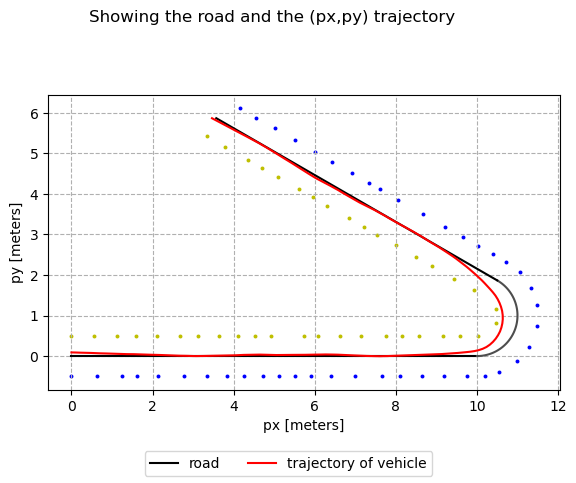

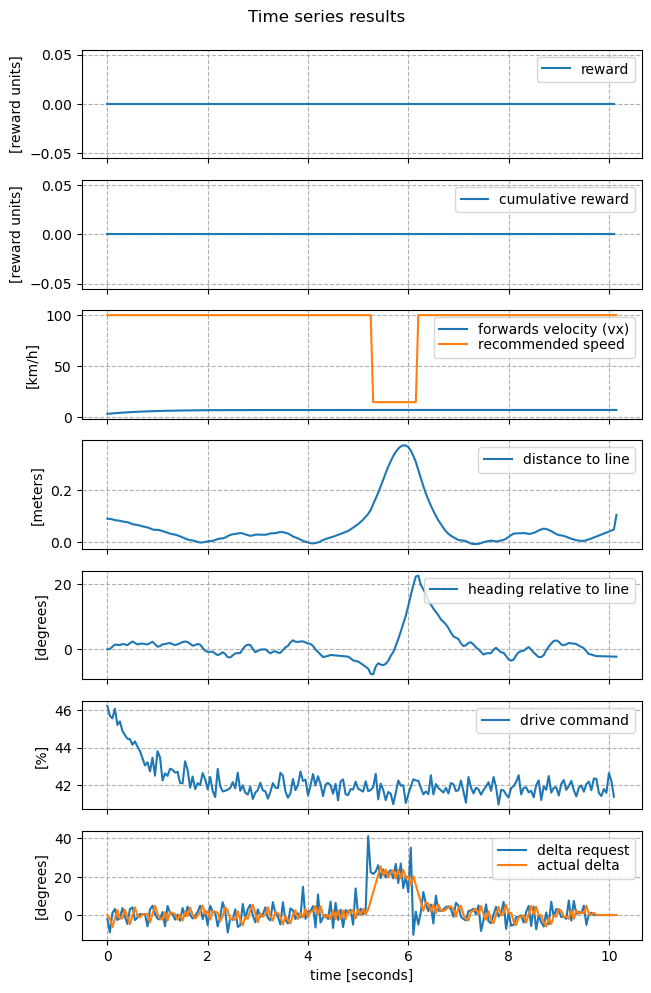

In [1051]:
# Import the function for simulating the autonomous driving environment
from evaluation.evaluation_for_autonomous_driving import simulate_policy
from evaluation.evaluation_for_autonomous_driving import plot_results_from_time_series_dict

# Specify the length of the simulation in time steps
# > If termination or truncation is flagged by the "step" function,
#   Then, the simulation ends.
N_sim = 380

# Specify the seed for when the simulate function resets the random number generator
sim_seed = 1;

# Initialize the Cone Following Policy class
cone_following_policy = PIDPolicyForConeFollowing()

# Call the function for simulating a given policy
sim_time_series_dict = simulate_policy(env_with_reward_wrapper, N_sim, cone_following_policy, seed=sim_seed, verbose=1)

# Call the plotting function
file_name_suffix = "example"
plot_details_list = plot_results_from_time_series_dict(env_base, sim_time_series_dict, path_for_saving_figures, file_name_suffix, should_plot_reward=True)

### Animate the time series results

We first define a function to make it easier to create animations. Then call the function for the simulation results produced in the previous cell.

In [938]:
def animate_from_sim_time_series_dict(sim_time_series_dict, Ts, path_for_saving_figures):
    # Extract the necessary trajectory information from the "sim_time_series_dict"
    px_traj    = sim_time_series_dict["px"]
    py_traj    = sim_time_series_dict["py"]
    theta_traj = sim_time_series_dict["theta"]
    delta_traj = sim_time_series_dict["delta"]
    # Call the environments function to create the simulation
    ani = env_with_reward_wrapper.unwrapped.render_matplotlib_animation_of_trajectory(px_traj, py_traj, theta_traj, delta_traj, Ts, traj_increment=3, zoom_width=6, zoom_height=6)
    # Save the animation
    ani.save(f"{path_for_saving_figures}/trajectory_animation.gif")
    print(f'Saved animation at {path_for_saving_figures}/trajectory_animation.gif')
    # Return the animation object
    return ani

Saved animation at models/cone_following/eval/trajectory_animation.gif


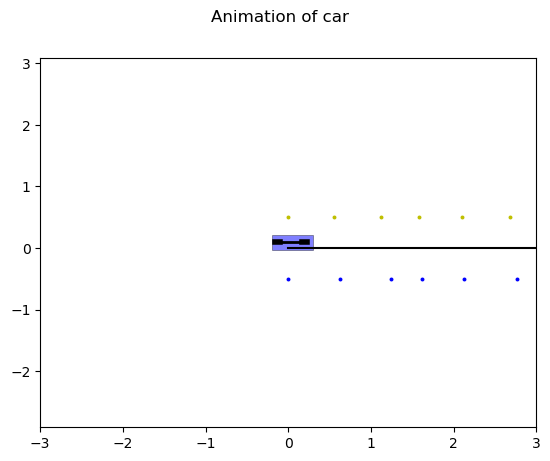

In [939]:
# Call the animation functoin
ani = animate_from_sim_time_series_dict(sim_time_series_dict, numerical_integration_parameters["Ts"], path_for_saving_figures)
# Display the animation
from IPython.display import HTML
HTML(ani.to_jshtml())